In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv')

Today, we will explore a dataset on the cost of treatment for different patients. The cost of treatment depends on many factors, including diagnosis, type of clinic, city of residence, age, and so on. We have no data on patients' diagnoses. But we have other information that can help us draw conclusions about patients' health and perform regression analysis. Let's look at our data.

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Let's look at our data to understand it better. Since we are primarily interested in the amount of costs, see which posts are more correlated with charges. For a start, we will encode categorical features.

In [6]:
# Label encoding

from sklearn.preprocessing import LabelEncoder

# Separate encoders
sex_le = LabelEncoder()
smoker_le = LabelEncoder()
region_le = LabelEncoder()

# Encoding
df['sex'] = sex_le.fit_transform(df['sex'])
df['smoker'] = smoker_le.fit_transform(df['smoker'])
df['region'] = region_le.fit_transform(df['region'])


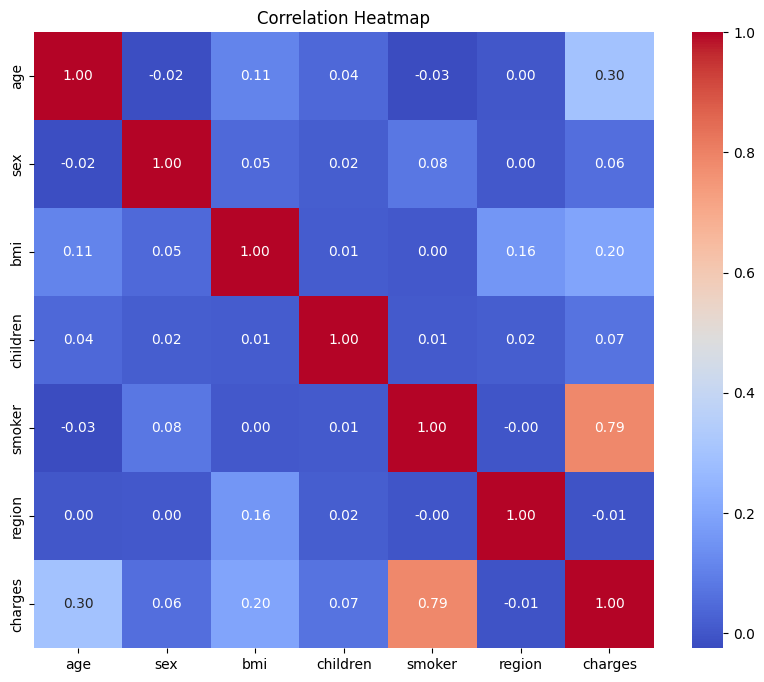

In [7]:
# Check correlation between variables - Higher the better
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

A strong correlation is observed only with the patient's smoking. I expected a higher correlation with BMI. Well, we investigate smoking in more detail.

First, let's look at the distribution of charges. This will help us to know how much patients spend on treatment on average.

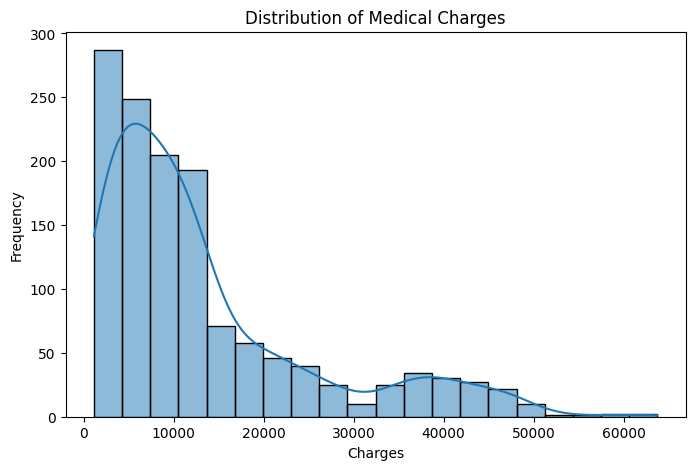

In [8]:
# Check the skewness of the target variable
plt.figure(figsize=(8,5))

sns.histplot(df['charges'], bins=20, kde=True)

plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

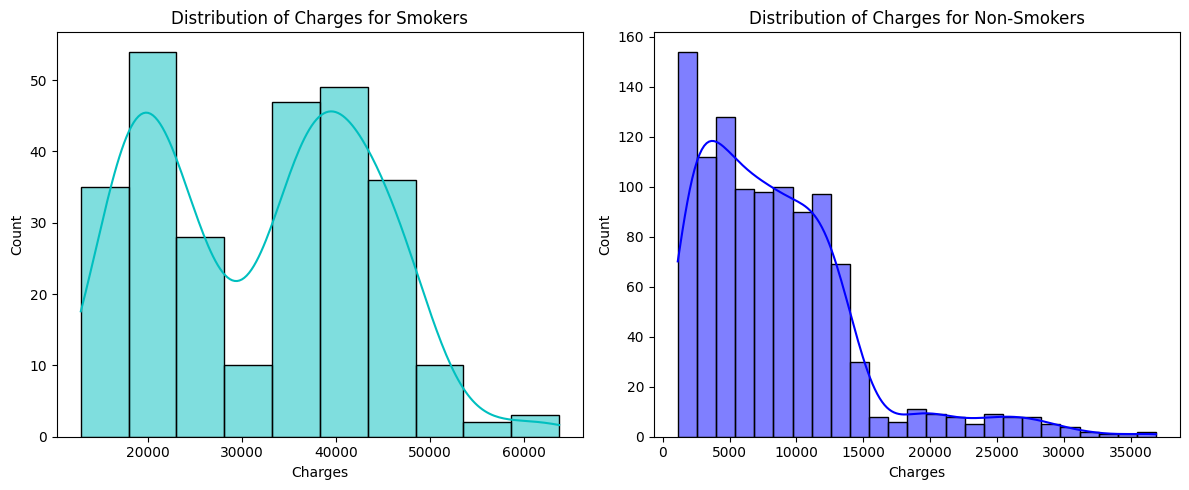

In [9]:
f = plt.figure(figsize=(12,5))

# Smokers
ax = f.add_subplot(121)
sns.histplot(df[df.smoker == 1]['charges'], kde=True, color='c', ax=ax)

ax.set_title('Distribution of Charges for Smokers')
ax.set_xlabel('Charges')


# Non-smokers
ax = f.add_subplot(122)
sns.histplot(df[df.smoker == 0]['charges'], kde=True, color='b',ax=ax)

ax.set_title('Distribution of Charges for Non-Smokers')
ax.set_xlabel('Charges')

plt.tight_layout()
plt.show()

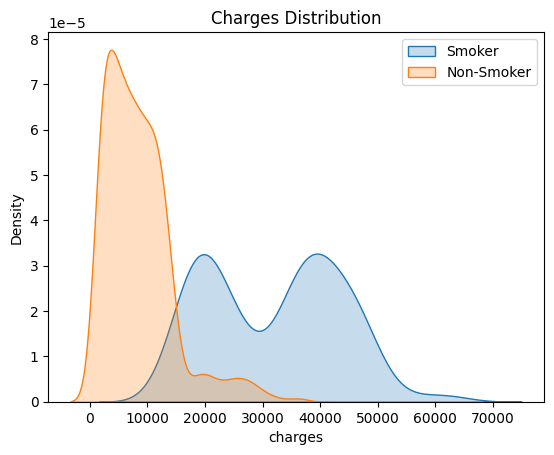

In [10]:
sns.kdeplot(data=df[df['smoker']==1], x='charges', fill=True, label='Smoker')

sns.kdeplot(data=df[df['smoker']==0], x='charges', fill=True, label='Non-Smoker')

plt.legend()
plt.title("Charges Distribution")

plt.show()

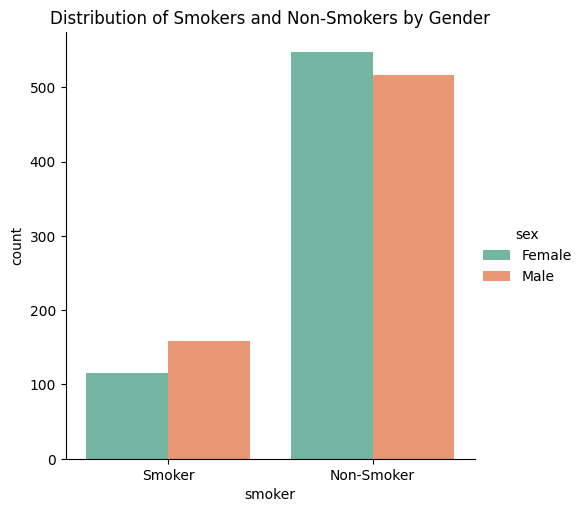

In [11]:
df['sex'] = df['sex'].replace({0: 'Female', 1: 'Male'})

df['smoker'] = df['smoker'].replace({0: 'Non-Smoker', 1: 'Smoker'})

sns.catplot(x="smoker", kind="count", hue="sex", palette="Set2", data=df)

plt.title("Distribution of Smokers and Non-Smokers by Gender")

plt.show()

The visualization indicates that the number of non-smokers is significantly higher than that of smokers. It can also be observed that male smokers slightly outnumber female smokers.

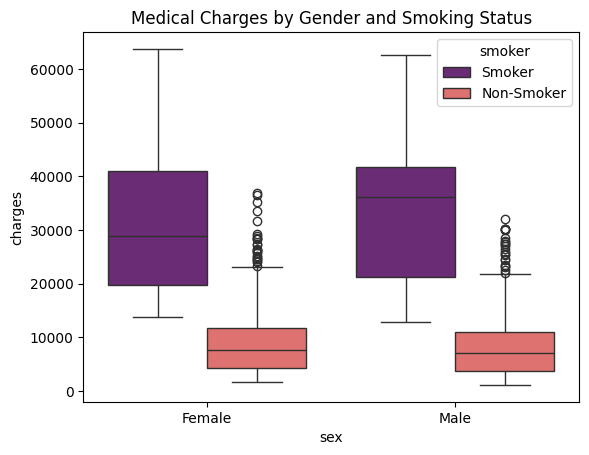

In [12]:
sns.boxplot(x='sex',y='charges', hue='smoker', data=df, palette='magma')

plt.title("Medical Charges by Gender and Smoking Status")

plt.show()

Now, let's focus on the patients' ages. First, let's look at how age affects treatment costs and which age group is most represented in our dataset.

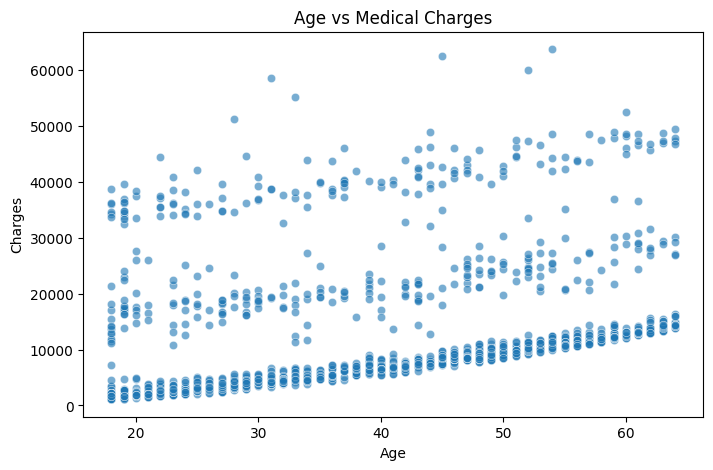

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot( x='age', y='charges', data=df, alpha=0.6)

plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

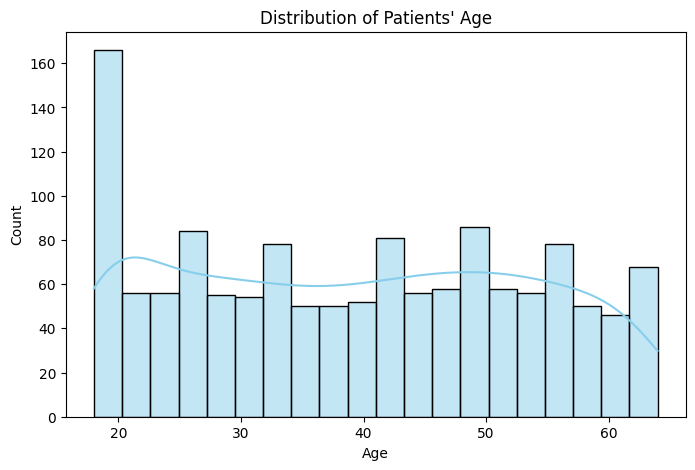

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True, color='skyblue')

plt.title("Distribution of Patients' Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

We have patients under 20 in our data set. 18 is the minimum age of patients in our set. The maximum age is 64 years. My personal interest is whether there are smokers among patients aged 18 years.

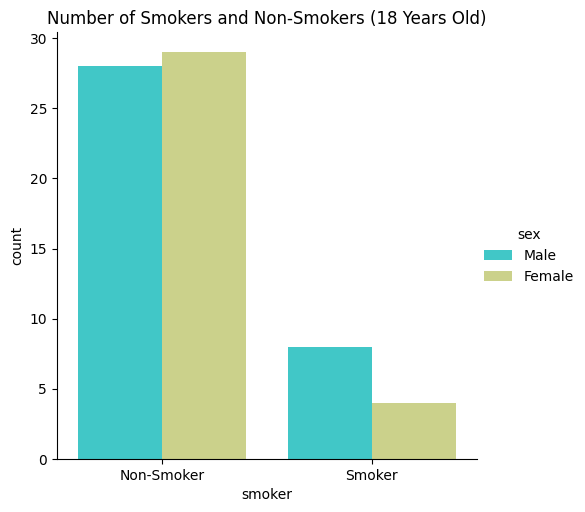

In [15]:
sns.catplot( x="smoker", kind="count", hue='sex', palette="rainbow", data=df[df.age == 18])

plt.title("Number of Smokers and Non-Smokers (18 Years Old)")

plt.show()

Oh. I was hoping the result would be different. 18 years old - a very young age. Does smoking affect the cost of treatment at this age?

/tmp/ipykernel_344/1342976557.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot( y="smoker", x="charges", data=df[df.age == 18], orient="h", palette="pink")


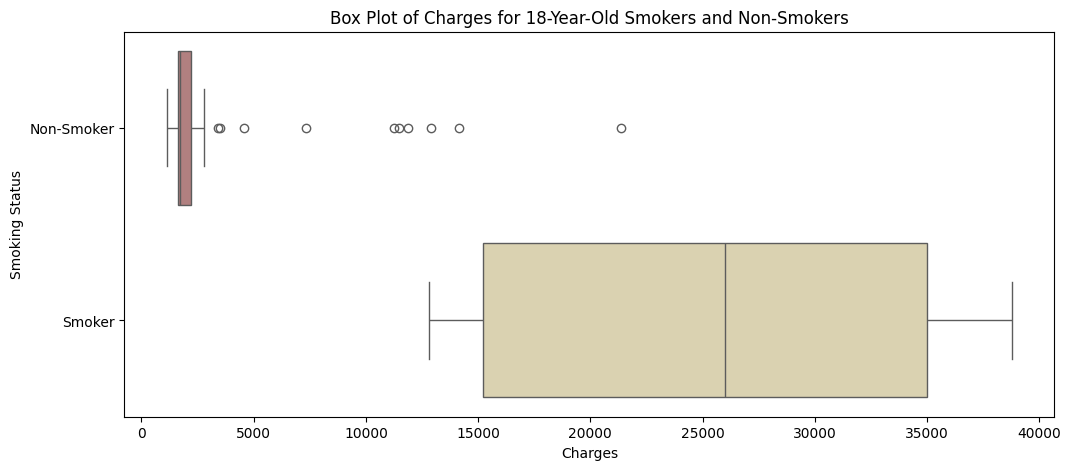

In [16]:
plt.figure(figsize=(12,5))

plt.title("Box Plot of Charges for 18-Year-Old Smokers and Non-Smokers")

sns.boxplot( y="smoker", x="charges", data=df[df.age == 18], orient="h", palette="pink")

plt.xlabel("Charges")
plt.ylabel("Smoking Status")

plt.show()

Oh. As we can see, even at the age of 18, smokers spend much more on treatment than non-smokers. Among non-smokers, we are seeing some "tails." I assume this is due to a serious illness or an accident. 

Now let's see how the cost of treatment depends on the age of smokers and non-smoker patients.

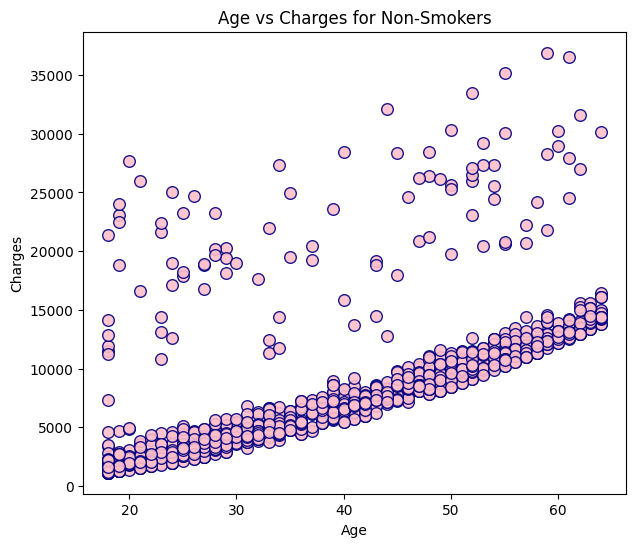

In [17]:
# Non-Smokers Scatter Plot
plt.figure(figsize=(7,6))

plt.scatter( x=df[df.smoker == 'Non-Smoker']['age'], y=df[df.smoker == 'Non-Smoker']['charges'], s=70, edgecolor='navy', color='pink', alpha=0.9)

plt.title("Age vs Charges for Non-Smokers")

plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

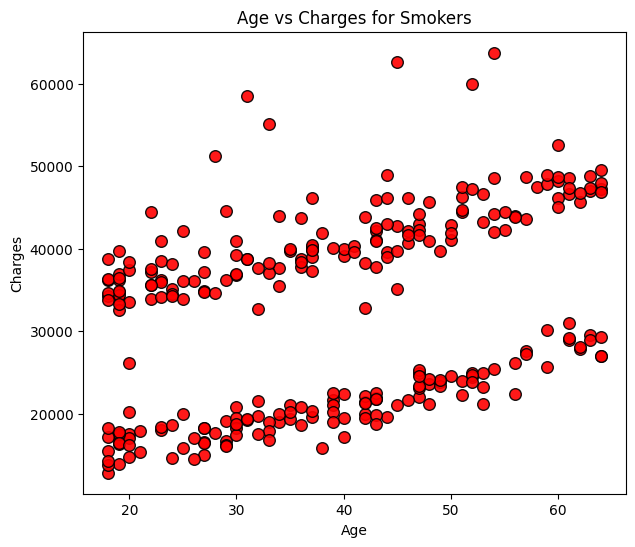

In [18]:
# Smokers Scatter Plot
plt.figure(figsize=(7,6))

plt.scatter( x=df[df.smoker == 'Smoker']['age'], y=df[df.smoker == 'Smoker']['charges'], s=70, edgecolor='black', color='red', alpha=0.9)

plt.title("Age vs Charges for Smokers")

plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

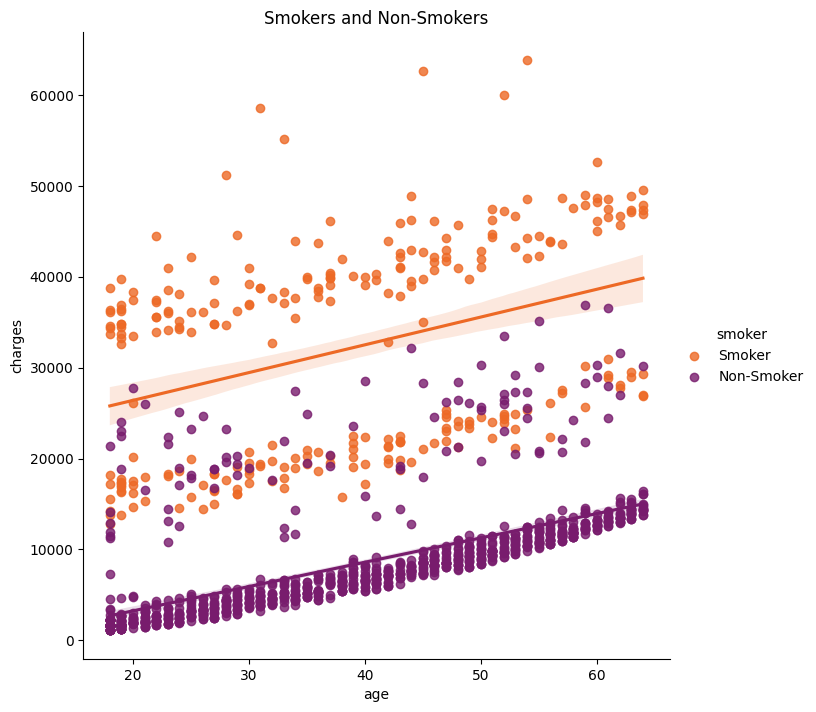

In [19]:
sns.lmplot( x="age", y="charges", hue="smoker", data=df, palette='inferno_r', height=7)

plt.title("Smokers and Non-Smokers")

plt.show()

In non-smokers, treatment costs increase with age. That makes sense. In smokers, we do not see such dependence. It is not only in smoking but also in the dataset's peculiarities. Such a strong effect of Smoking on treatment costs would be more logically evaluated using a large dataset and clear signs. 

But we work with what we have! Let's pay attention to BMI. I am surprised that this figure affects treatment costs for patients. Or are we on a diet for nothing?

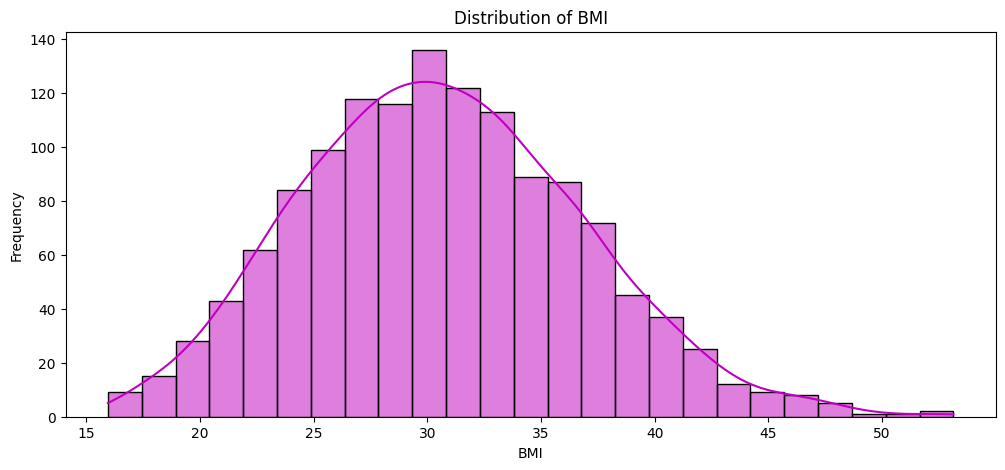

In [20]:
plt.figure(figsize=(12,5))

plt.title("Distribution of BMI")
sns.histplot(df["bmi"], kde=True, color='m')

plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

The average BMI in patients is 30. At a value of 30, obesity begins. I also calculated my BMI, and now I can safely eat a pizza. 

Let's start to explore! First, let's look at the distribution of costs among patients with a BMI greater than 30 and those with a BMI less than 30.

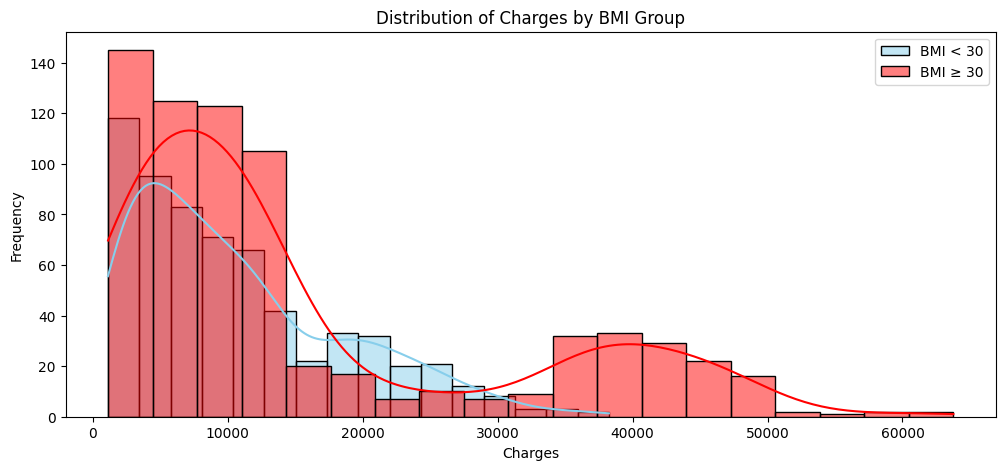

In [21]:
plt.figure(figsize=(12,5))

# BMI below 30
sns.histplot( df[df['bmi'] < 30]['charges'], color='skyblue', kde=True, label='BMI < 30')

# BMI 30 and above
sns.histplot( df[df['bmi'] >= 30]['charges'], color='red', kde=True, label='BMI ≥ 30')

plt.title("Distribution of Charges by BMI Group")

plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.legend()

plt.show()

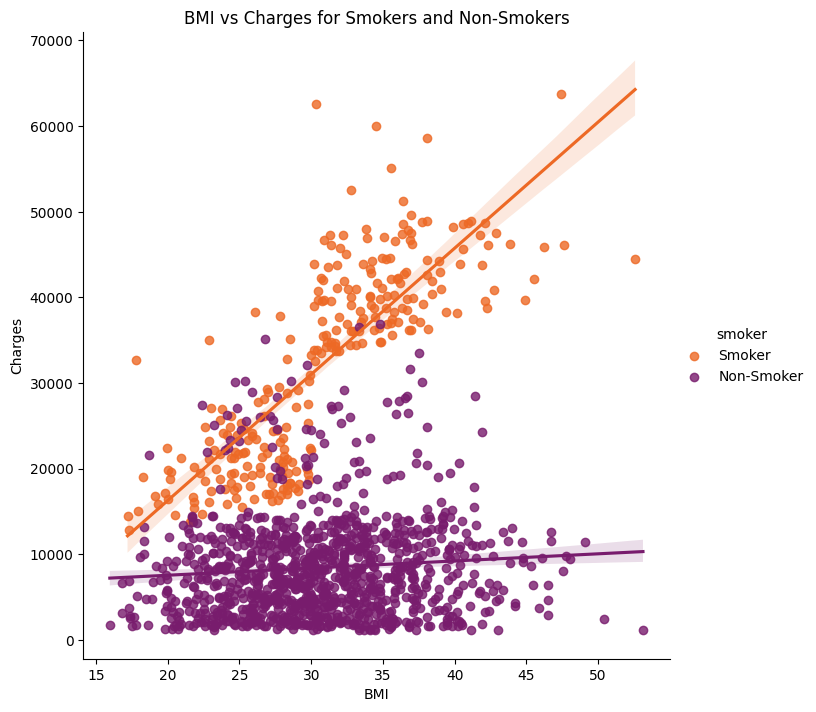

In [22]:
sns.lmplot( x="bmi", y="charges", hue="smoker", data=df, palette='inferno_r', height=7)

plt.title("BMI vs Charges for Smokers and Non-Smokers")

plt.xlabel("BMI")
plt.ylabel("Charges")

plt.show()

Let's pay attention to children. First, let's see how many children our patients have.

/tmp/ipykernel_344/15076878.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot( x='children', data=df, palette='Set2')


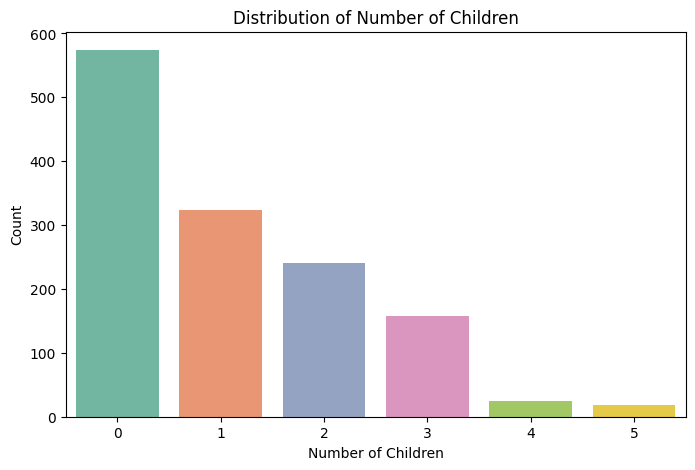

In [23]:
plt.figure(figsize=(8,5))

sns.countplot( x='children', data=df, palette='Set2')

plt.title("Distribution of Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Count")

plt.show()

Most patients do not have children. Perfectly, some have 5 children! Children are happy :)

Do people who have children smoke?

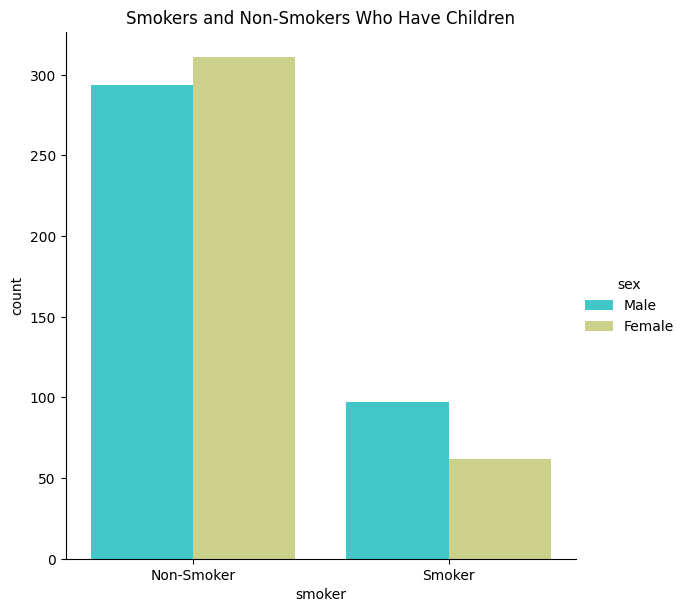

In [24]:
sns.catplot( x="smoker", kind="count", hue="sex", palette="rainbow", data=df[df.children > 0], height=6)

plt.title("Smokers and Non-Smokers Who Have Children")

plt.show()

Now lets make a model.

In [25]:
# Convert categorical columns back into numbers

le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])

In [26]:
df['sex'] = df['sex'].replace({'Female': 0, 'Male': 1})

df['smoker'] = df['smoker'].replace({'Non-Smoker': 0, 'Smoker': 1})

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [28]:
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

In [30]:
lm.coef_         #It shows how much each variable is important for our model

array([ 2.57056264e+02, -1.87914567e+01,  3.35781491e+02,  4.25091456e+02,
        2.36478181e+04, -2.71284266e+02])

In [31]:
cdf = pd.DataFrame(lm.coef_, X.columns, columns=['coef_'])    #It shows 'Length of Membership' has the highest impact on targeted variable
print(cdf)

                 coef_
age         257.056264
sex         -18.791457
bmi         335.781491
children    425.091456
smoker    23647.818096
region     -271.284266


In [32]:
# predictions
predictions = lm.predict(X_test)

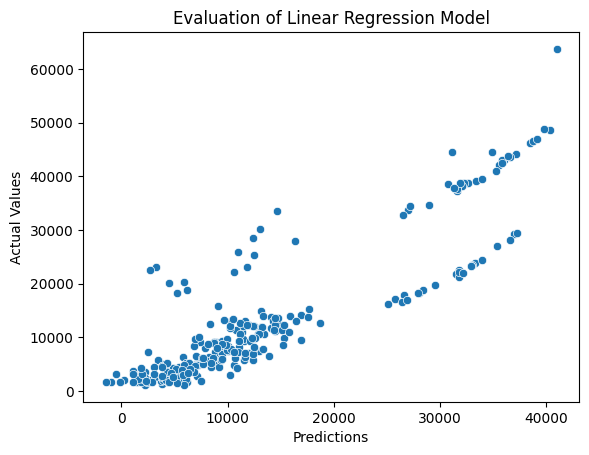

In [33]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel("Predictions")
plt.ylabel("Actual Values")
plt.title("Evaluation of Linear Regression Model")
plt.show()

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

print('Mean Abssolute Error', mean_absolute_error(y_test, predictions))
print('Mean Squared Error', mean_squared_error(y_test, predictions))
print('RMSE', math.sqrt(mean_squared_error(y_test, predictions)))

from sklearn.metrics import r2_score

# R² Score
r2 = r2_score(y_test, predictions)

print("R² Score:", r2)

Mean Abssolute Error 4186.508898366433
Mean Squared Error 33635210.431178406
RMSE 5799.587091438356
R² Score: 0.7833463107364539


In [35]:
# residuals - distance between actual and predicted point

residuals = y_test - predictions

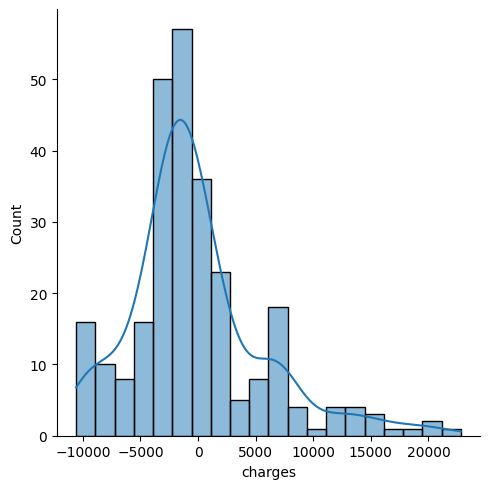

In [36]:
# checking normality because the model assumes the residuals suppose to be random

sns.displot(residuals, bins=20, kde=True)

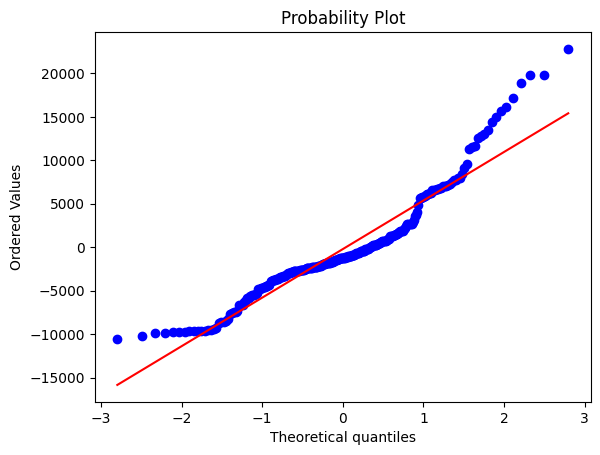

In [37]:
#QQ plot for checking normality v reidual - straight line means we are safe

import pylab
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()